# LLM vs LLVM Optimizer Benchmark

Each LLM is loaded **one at a time**, results are **flushed to its own CSV** immediately after,  
then the model is fully unloaded and VRAM is reclaimed before the next model loads.
All CSVs are merged at the end for plotting.

**Safe to re-run**: if a model's CSV already exists it is skipped automatically — you can interrupt  
and resume without re-running completed models.

| Handle | HuggingFace repo |
|---|---|
| `qwen3.5_0.8b_reasoning`    | `Qwen/Qwen3.5-0.8B` |
| `qwen3.5_0.8b_nonreasoning` | `Qwen/Qwen3.5-0.8B` |
| `qwen3.5_2b_reasoning`      | `Qwen/Qwen3.5-2B` |
| `qwen3.5_2b_nonreasoning`   | `Qwen/Qwen3.5-2B` |
| `nanbeige4.1_3b`            | `Nanbeige/Nanbeige4.1-3B` |

**LLVM baselines** read from `compare.py`: `baseline`, `const_prop`, `combine_dce`, `inline_first`, `sccp_first`, `O1`, `O2`, `O3`

## 0 · Install dependencies

In [27]:
!pip install ipywidgets

In [28]:
!pip install jupyterlab_widgets

In [29]:
!pip install -q transformers accelerate torch sentencepiece pandas matplotlib seaborn tqdm

## 1 · Configuration — edit here

In [30]:
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────────
SUITE_DIR    = Path("./llvm-test-suite")       # root of llvm-test-suite
SUBDIR       = "SingleSource"                   # sub-directory to scan
COMPARE_PY   = Path("./compare.py")            # your compare.py
WORK_DIR     = Path("./ll-files/llm-bench")    # IR / binary scratch space
RESULTS_DIR  = Path("./ll-files/results")      # one CSV per model lands here
FINAL_CSV    = Path("./ll-files/final_report.csv")  # merged at the end

# ── Scan limits ────────────────────────────────────────────────────────────────
MAX_FILES  = 1000      # 0 = all files
SRC_EXT    = [".c"]

# ── LLM settings ───────────────────────────────────────────────────────────────
MAX_IR_CHARS   = 2000    # characters of IR sent to the model (keep small for 8 GB)
MAX_NEW_TOKENS = 80
LLM_DEVICE     = "cuda"    # change to "cpu" if needed
LLM_DTYPE      = "float16" # float16 saves VRAM on a 4060

# Set True to overwrite per-model CSVs even if they already exist.
FORCE_RERUN_MODELS = True

# ── Model registry ─────────────────────────────────────────────────────────────
# (display_name, hf_repo, prompt_style)
# prompt_style: "instruct" -> chat template  |  "completion" -> raw text
MODEL_REGISTRY = [
    ("qwen3.5_0.8b_reasoning",    "Qwen/Qwen3.5-0.8B",      "instruct"),
    ("qwen3.5_0.8b_nonreasoning", "Qwen/Qwen3.5-0.8B",      "instruct"),
    ("qwen3.5_2b_reasoning",      "Qwen/Qwen3.5-2B",        "instruct"),
    ("qwen3.5_2b_nonreasoning",   "Qwen/Qwen3.5-2B",        "instruct"),
    ("nanbeige4.1_3b",            "Nanbeige/Nanbeige4.1-3B", "instruct"),
]

# ── Fallback pipelines (used only if compare.py is missing) ───────────────────
FALLBACK_CUSTOM = {
    "baseline":     "",
    "const_prop":   "sccp",
    "combine_dce":  "instcombine,dce",
    "inline_first": "cgscc(inline),function(sccp)",
    "sccp_first":   "function(sccp),cgscc(inline)",
}
FALLBACK_OPT = ["O1", "O2", "O3"]

# ── CSV columns shared across all result files ─────────────────────────────────
CSV_FIELDS = ["source", "pipeline", "status", "reason",
              "exe_size", "compile_time_s", "llm_infer_s", "llm_raw_output"]

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR.mkdir(parents=True, exist_ok=True)
FINAL_CSV.parent.mkdir(parents=True, exist_ok=True)
print("Config OK.  Results dir:", RESULTS_DIR)

Config OK.  Results dir: ll-files/results


## 2 · Shared utilities

In [31]:
import ast, csv, gc, os, re, shutil, subprocess, textwrap, time
import torch

# ── Shell ──────────────────────────────────────────────────────────────────────
def run_cmd(args, cwd=None):
    r = subprocess.run(args, cwd=cwd, text=True,
                       stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    return r.returncode == 0, r.stdout, r.stderr

# ── Pipeline loader ────────────────────────────────────────────────────────────
def load_pipelines(path: Path):
    if not path.exists():
        print(f"[warn] {path} not found — using fallbacks.")
        return FALLBACK_CUSTOM, FALLBACK_OPT
    tree = ast.parse(path.read_text(encoding="utf-8"))
    cp = ol = None
    for node in tree.body:
        if not isinstance(node, ast.Assign): continue
        for t in node.targets:
            if isinstance(t, ast.Name):
                if t.id == "custom_pipelines": cp = ast.literal_eval(node.value)
                if t.id == "opt_levels":        ol = ast.literal_eval(node.value)
    return (cp or FALLBACK_CUSTOM), (ol or FALLBACK_OPT)

# ── File discovery ─────────────────────────────────────────────────────────────
def discover_sources(root: Path, exts):
    return sorted(p for p in root.rglob("*") if p.is_file() and p.suffix in exts)

def safe_id(path, root):
    return str(path.relative_to(root)).replace(os.sep, "__")

# ── opt pass-string sanitiser ──────────────────────────────────────────────────
_VALID = re.compile(r'^[a-zA-Z0-9,()\-_\s]+$')
_STRIP_TRAIL = '.,;"\'`'
PASS_ALIASES = {
    "cfgsimplify": "simplifycfg",
    "simplify-cfg": "simplifycfg",
    "simplifycfg": "simplifycfg",
    "instcombinepass": "instcombine",
    "deadcodeelim": "dce",
    "deadcodeelimination": "dce",
    "sccppass": "sccp",
    "loopunroll": "loop-unroll",
    "jumpthreading": "jump-threading",
    "tailcallelimination": "tailcallelim",
}
SAFE_PASSES = [
    "mem2reg", "instcombine", "simplifycfg", "gvn", "licm",
    "loop-unroll", "dce", "inline", "sccp", "adce",
    "tailcallelim", "jump-threading", "early-cse",
    "sroa", "reassociate", "loop-rotate", "indvars",
]
SAFE_PASS_SET = set(SAFE_PASSES)

def _normalize_pass(tok: str) -> str:
    s = tok.strip().lower().replace("_", "-")
    s = re.sub(r"[^a-z0-9\-]", "", s)
    return PASS_ALIASES.get(s, s)

def _passes_from_text(raw: str):
    toks = re.findall(r"[A-Za-z][A-Za-z0-9_\-]*", raw or "")
    out = []
    for t in toks:
        p = _normalize_pass(t)
        if p in SAFE_PASS_SET and p not in out:
            out.append(p)
    return out

def sanitize_passes(raw: str):
    raw = (raw or "").strip()
    if not raw:
        return None

    cleaned = re.sub(r"<think>.*?</think>", " ", raw, flags=re.DOTALL | re.IGNORECASE)
    cleaned = re.sub(r"```[\w]*", "", cleaned).replace("```", " ")
    cleaned = cleaned.replace("`", " ").strip()

    # 1) Direct -passes= extraction if present.
    m = re.search(r"-passes=[\"\']?([^\"\'\n]+)", cleaned, re.IGNORECASE)
    if m:
        cand = m.group(1).strip().rstrip(_STRIP_TRAIL)
        if _VALID.match(cand) and len(cand) < 300:
            return cand

    # 2) Try robust pass-token extraction from arbitrary text.
    hits = _passes_from_text(cleaned)
    if len(hits) >= 2:
        return ",".join(hits[:7])

    # 3) Fallback: accept concise line only if it contains known pass names.
    for line in cleaned.splitlines():
        line = line.strip().rstrip(_STRIP_TRAIL)
        if not line or len(line) >= 300 or not _VALID.match(line):
            continue
        line_hits = _passes_from_text(line)
        if len(line_hits) >= 2:
            return ",".join(line_hits[:7])

    return None

# ── Per-source build recipe ────────────────────────────────────────────────────
LEGACY_C_FLAGS = [
    "-std=gnu89",
    "-Wno-error=implicit-int",
    "-Wno-error=implicit-function-declaration",
    "-Wno-error=deprecated-non-prototype",
]

def get_build_recipe(src: Path):
    """Return compile/link helper flags needed for specific benchmark families."""
    recipe = {"cflags": [], "link_sources": []}
    p = src.as_posix()

    # Polybench files need utilities include path, FP tolerance define, and runtime source.
    if "/SingleSource/Benchmarks/Polybench/" in p:
        poly_root = next((par for par in src.parents if par.name == "Polybench"), None)
        if poly_root is not None:
            util_dir = poly_root / "utilities"
            recipe["cflags"] += [
                "-I", str(util_dir.resolve()),
                "-DFP_ABSTOLERANCE=1e-5",
            ]
            polybench_c = util_dir / "polybench.c"
            if polybench_c.exists():
                recipe["link_sources"].append(polybench_c)

    return recipe

def needs_legacy_c_fallback(stderr: str):
    markers = [
        "does not support implicit int",
        "-Wimplicit-int",
        "deprecated-non-prototype",
        "implicit-function-declaration",
    ]
    return any(m in stderr for m in markers)

# ── LLVM compile helpers ───────────────────────────────────────────────────────
def compile_to_base_ir(src: Path, out_ir: Path):
    out_ir.parent.mkdir(parents=True, exist_ok=True)
    recipe = get_build_recipe(src)

    base_cmd = [
        "clang",
        "-O0",
        "-S",
        "-emit-llvm",
        *recipe["cflags"],
        str(src.resolve()),
        "-o",
        str(out_ir.resolve()),
    ]
    ok, _, err = run_cmd(base_cmd)
    if ok:
        return True, "", recipe

    # Retry old C code with compatibility flags (Dhrystone, fbench, ReedSolomon, etc.).
    if needs_legacy_c_fallback(err):
        retry_recipe = {
            "cflags": recipe["cflags"] + LEGACY_C_FLAGS,
            "link_sources": recipe["link_sources"],
        }
        retry_cmd = [
            "clang",
            "-O0",
            "-S",
            "-emit-llvm",
            *retry_recipe["cflags"],
            str(src.resolve()),
            "-o",
            str(out_ir.resolve()),
        ]
        ok2, _, err2 = run_cmd(retry_cmd)
        if ok2:
            return True, "", retry_recipe
        return False, err2.strip(), recipe

    return False, err.strip(), recipe

def apply_and_link(base_ir, opt_ir, exe, passes=None, opt_level=None, recipe=None):
    """Returns (ok, reason, elapsed_s)"""
    t0 = time.time()
    base_ir = base_ir.resolve()
    opt_ir  = opt_ir.resolve()
    exe     = exe.resolve()
    recipe  = recipe or {"cflags": [], "link_sources": []}

    if passes == "":
        try:
            shutil.copyfile(base_ir, opt_ir)
            opt_ok, opt_err = True, ""
        except OSError as e:
            return False, str(e), time.time()-t0
    elif opt_level:
        opt_ok, _, opt_err = run_cmd(
            ["opt", f"-{opt_level}", str(base_ir), "-S", "-o", str(opt_ir)])
    else:
        opt_ok, _, opt_err = run_cmd(
            ["opt", f"-passes={passes}", str(base_ir), "-S", "-o", str(opt_ir)])
    if not opt_ok:
        return False, f"opt: {opt_err.replace(chr(10),' | ')}", time.time()-t0

    link_cmd = ["clang", str(opt_ir), *recipe["cflags"]]
    link_cmd.extend(str(p.resolve()) for p in recipe["link_sources"])
    link_cmd.extend(["-O0", "-lm", "-o", str(exe)])

    lk_ok, _, lk_err = run_cmd(link_cmd)
    elapsed = time.time()-t0
    if not lk_ok:
        return False, f"link: {lk_err.replace(chr(10),' | ')}", elapsed
    return True, "", elapsed

# ── CSV helpers ────────────────────────────────────────────────────────────────
def flush_rows(rows: list, path: Path):
    """Append rows to a CSV, writing header only when file is new/empty."""
    write_header = not path.exists() or path.stat().st_size == 0
    with path.open("a", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=CSV_FIELDS)
        if write_header:
            w.writeheader()
        w.writerows(rows)

def make_row(src, source_root, pipeline, status,
             reason="", exe_size="", compile_time="",
             llm_time="", raw_output=""):
    return {
        "source":         str(src.relative_to(source_root)),
        "pipeline":       pipeline,
        "status":         status,
        "reason":         reason,
        "exe_size":       exe_size,
        "compile_time_s": compile_time,
        "llm_infer_s":    llm_time,
        "llm_raw_output": raw_output,
    }

# ── VRAM flush ─────────────────────────────────────────────────────────────────
def free_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    used = torch.cuda.memory_allocated()/1e9 if torch.cuda.is_available() else 0
    print(f"  VRAM after unload: {used:.2f} GB allocated")

print("Utilities ready.")

Utilities ready.


## 3 · Discover sources & compile base IR (once)

In [32]:
from tqdm.notebook import tqdm

custom_pipelines, opt_levels = load_pipelines(COMPARE_PY)
source_root = (SUITE_DIR / SUBDIR).resolve() if SUBDIR else SUITE_DIR.resolve()
sources = discover_sources(source_root, set(SRC_EXT))
if MAX_FILES > 0:
    sources = sources[:MAX_FILES]

ALL_LLVM = list(custom_pipelines.keys()) + opt_levels
ALL_LLM  = [m[0] for m in MODEL_REGISTRY]

print(f"Source root : {source_root}")
print(f"Sources     : {len(sources)}")
print(f"LLVM pipes  : {ALL_LLVM}")
print(f"LLM models  : {ALL_LLM}")

Source root : /media/sasank-v/New Volume/Studies/College/VIT/Sem 6/Compiler Design/DA/llvm-test-suite/SingleSource
Sources     : 1000
LLVM pipes  : ['baseline', 'const_prop', 'combine_dce', 'inline_first', 'sccp_first', 'O1', 'O2', 'O3']
LLM models  : ['qwen3.5_0.8b_reasoning', 'qwen3.5_0.8b_nonreasoning', 'qwen3.5_2b_reasoning', 'qwen3.5_2b_nonreasoning', 'nanbeige4.1_3b']


In [33]:
# ── LLVM baselines: compile to base IR + run all LLVM pipelines ───────────────
# base.ll files are ALWAYS (re-)compiled if missing on disk — this is fast and
# idempotent. LLVM pipeline runs (opt + link) are skipped if llvm_baselines.csv
# already exists (they are the slow part).

LLVM_CSV     = RESULTS_DIR / "llvm_baselines.csv"
base_ir_map  = {}   # src Path -> base.ll Path  (None = compile failed)
build_recipe_map = {}  # src Path -> compile/link recipe for that benchmark

llvm_csv_exists = LLVM_CSV.exists() and LLVM_CSV.stat().st_size > 0
if llvm_csv_exists:
    print(f"[info] {LLVM_CSV.name} already exists — skipping LLVM pipeline runs.")
    print(      "       Re-compiling any missing base IR files …")
else:
    print("Running LLVM baselines + compiling base IR …")

llvm_rows    = []    # only populated when we actually run LLVM pipelines
recompiled   = 0
already_ok   = 0
compile_fail = 0

for src in tqdm(sources, desc="base IR"):
    tid     = safe_id(src, source_root)
    tdir    = WORK_DIR / tid
    tdir.mkdir(parents=True, exist_ok=True)
    base_ir = tdir / "base.ll"

    # ── Re-use existing base.ll if it looks valid (non-empty) ────────────────
    if base_ir.exists() and base_ir.stat().st_size > 0:
        base_ir_map[src] = base_ir
        build_recipe_map[src] = get_build_recipe(src)
        already_ok += 1
    else:
        # Compile from source (fast, ~10-50 ms per file)
        ok, err, recipe = compile_to_base_ir(src, base_ir)
        if not ok:
            print(f"  [warn] base IR failed: {src.name}: {err[:180]}")
            base_ir_map[src] = None
            build_recipe_map[src] = None
            compile_fail += 1
        else:
            base_ir_map[src] = base_ir
            build_recipe_map[src] = recipe
            recompiled += 1

    # ── Run LLVM pipelines only when CSV does not exist yet ───────────────────
    if not llvm_csv_exists and base_ir_map[src] is not None:
        recipe = build_recipe_map[src]
        for name, passes in custom_pipelines.items():
            opt_ir = tdir / f"{name}.ll"
            exe    = tdir / f"{name}.out"
            ok2, reason, elapsed = apply_and_link(
                base_ir_map[src], opt_ir, exe, passes=passes, recipe=recipe)
            llvm_rows.append(make_row(
                src, source_root, name,
                "ok" if ok2 else "fail",
                reason=reason,
                exe_size=str(exe.stat().st_size) if ok2 else "",
                compile_time=f"{elapsed:.6f}",
            ))

        for level in opt_levels:
            opt_ir = tdir / f"{level}.ll"
            exe    = tdir / f"{level}.out"
            ok2, reason, elapsed = apply_and_link(
                base_ir_map[src], opt_ir, exe, opt_level=level, recipe=recipe)
            llvm_rows.append(make_row(
                src, source_root, level,
                "ok" if ok2 else "fail",
                reason=reason,
                exe_size=str(exe.stat().st_size) if ok2 else "",
                compile_time=f"{elapsed:.6f}",
            ))

if not llvm_csv_exists:
    flush_rows(llvm_rows, LLVM_CSV)
    print(f"Saved {len(llvm_rows)} LLVM rows → {LLVM_CSV}")

available = sum(1 for v in base_ir_map.values() if v is not None)
print(f"\nbase_ir_map summary:")
print(f"  Already on disk : {already_ok}")
print(f"  Re-compiled now : {recompiled}")
print(f"  Compile failed  : {compile_fail}")
print(f"  ─────────────────────")
print(f"  Available for LLM inference: {available} / {len(sources)}")

if available == 0:
    print("\n[ERROR] No base IR files are available!")
    print("  Check that clang is installed and SUITE_DIR points to the test suite.")

[info] llvm_baselines.csv already exists — skipping LLVM pipeline runs.
       Re-compiling any missing base IR files …


base IR:   0%|          | 0/1000 [00:00<?, ?it/s]

  [warn] base IR failed: symm.c: /media/sasank-v/New Volume/Studies/College/VIT/Sem 6/Compiler Design/DA/llvm-test-suite/SingleSource/Benchmarks/Polybench/linear-algebra/blas/symm/symm.c:117:6: error: redefinition
  [warn] base IR failed: polybench.c: /media/sasank-v/New Volume/Studies/College/VIT/Sem 6/Compiler Design/DA/llvm-test-suite/SingleSource/Benchmarks/Polybench/utilities/polybench.c:45:5: error: redefinition of 'polybe
  [warn] base IR failed: 20000822-1.c: /media/sasank-v/New Volume/Studies/College/VIT/Sem 6/Compiler Design/DA/llvm-test-suite/SingleSource/Regression/C/gcc-c-torture/execute/20000822-1.c:13:3: error: function definitio
  [warn] base IR failed: 20001111-1.c: /media/sasank-v/New Volume/Studies/College/VIT/Sem 6/Compiler Design/DA/llvm-test-suite/SingleSource/Regression/C/gcc-c-torture/execute/20001111-1.c:19:8: error: incompatible integ
  [warn] base IR failed: 20010209-1.c: /media/sasank-v/New Volume/Studies/College/VIT/Sem 6/Compiler Design/DA/llvm-test-suite/

## 4 · LLM engine — load / infer / unload

In [34]:
from transformers import AutoTokenizer, AutoModelForCausalLM

SYSTEM_PROMPT = textwrap.dedent("""\
    You are an expert LLVM compiler engineer.
    Given LLVM IR, output ONLY a single-line opt pass pipeline for `opt -passes=...`.
    Output format MUST be exactly comma-separated pass names only, for example:
    instcombine,dce,sccp
    No prose, no markdown, no code fences, no labels.
    Prefer 3-7 passes from this safe set:
    mem2reg,instcombine,simplifycfg,gvn,licm,loop-unroll,dce,inline,sccp,adce,tailcallelim,jump-threading,early-cse,sroa,reassociate,loop-rotate,indvars
""")


class LLMEngine:
    def __init__(self, name, repo, style):
        self.name  = name
        self.repo  = repo
        self.style = style
        self.tok   = None
        self.model = None

    def _is_3b_or_larger(self):
        return any(tag in self.name.lower() for tag in ["3b", "4b", "7b", "8b"])

    def load(self):
        dtype = getattr(torch, LLM_DTYPE) if LLM_DTYPE != "auto" else torch.float16
        print(f"  Loading {self.name}  ({self.repo})  [{LLM_DTYPE}] …")
        self.tok = AutoTokenizer.from_pretrained(
            self.repo, trust_remote_code=True)
        if self.tok.pad_token is None:
            self.tok.pad_token = self.tok.eos_token

        kwargs = {
            "trust_remote_code": True,
            "low_cpu_mem_usage": True,
        }

        if torch.cuda.is_available():
            kwargs["device_map"] = "auto"
            kwargs["max_memory"] = {0: "7.1GiB", "cpu": "64GiB"}
            kwargs["dtype"] = dtype
        else:
            kwargs["dtype"] = torch.float32

        # Use 4-bit for 3B+ models to fit 8GB GPUs reliably.
        if torch.cuda.is_available() and self._is_3b_or_larger():
            try:
                from transformers import BitsAndBytesConfig
                kwargs["quantization_config"] = BitsAndBytesConfig(
                    load_in_4bit=True,
                    bnb_4bit_quant_type="nf4",
                    bnb_4bit_use_double_quant=True,
                    bnb_4bit_compute_dtype=torch.float16,
                )
                print("  4-bit NF4 quantization enabled.")
            except Exception as qe:
                print(f"  [warn] bitsandbytes unavailable ({qe}); trying non-quantized load")

        self.model = AutoModelForCausalLM.from_pretrained(
            self.repo,
            **kwargs,
        ).eval()

        if not torch.cuda.is_available():
            self.model = self.model.to("cpu")

        used = torch.cuda.memory_allocated()/1e9 if torch.cuda.is_available() else 0
        print(f"  Ready. VRAM in use: {used:.2f} GB")

    def unload(self):
        """Delete model + tokenizer, run GC, flush CUDA cache."""
        try:
            if self.model is not None:
                del self.model
            if self.tok is not None:
                del self.tok
        finally:
            self.model = None
            self.tok = None
            free_vram()
            print(f"  {self.name} unloaded.")

    @torch.inference_mode()
    def suggest(self, ir_text: str):
        """Returns (passes_or_None, infer_time_s, raw_text)"""
        snippet  = ir_text[:MAX_IR_CHARS]
        user_msg = (
            "Return only comma-separated pass names with no extra text.\n"
            f"Optimize this LLVM IR:\n\n{snippet}\n\nPass pipeline:"
        )

        if self.style == "instruct" and hasattr(self.tok, "apply_chat_template"):
            msgs = [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_msg},
            ]
            # Qwen3.5 defaults to non-thinking; enable it only for reasoning handles.
            enable_thinking = self.name.startswith("qwen3.5_") and self.name.endswith("_reasoning")
            if enable_thinking:
                try:
                    prompt = self.tok.apply_chat_template(
                        msgs, tokenize=False, add_generation_prompt=True, enable_thinking=True
                    )
                except TypeError:
                    prompt = self.tok.apply_chat_template(
                        msgs, tokenize=False, add_generation_prompt=True
                    )
            else:
                prompt = self.tok.apply_chat_template(
                    msgs, tokenize=False, add_generation_prompt=True
                )
        else:
            prompt = (
                f"### Instruction:\n{SYSTEM_PROMPT}\n\n"
                f"### Input:\n{user_msg}\n\n"
                "### Response:\n"
            )

        # Handle both fully-GPU and device_map='auto' placement.
        model_device = next(self.model.parameters()).device
        inputs = self.tok(
            prompt, return_tensors="pt",
            truncation=True, max_length=1024
        ).to(model_device)

        t0  = time.time()
        out = self.model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=self.tok.eos_token_id,
            min_new_tokens=5,
            repetition_penalty=1.02,
        )
        elapsed = time.time() - t0

        gen_ids = out[0][inputs["input_ids"].shape[-1]:]
        raw     = self.tok.decode(gen_ids, skip_special_tokens=True)
        return sanitize_passes(raw), elapsed, raw


print("LLMEngine defined.")

LLMEngine defined.


## 5 · Run each LLM — load → infer all files → flush CSV → unload

- Each model writes to `results/<model_name>.csv`
- Results are flushed to disk every **10 files** (crash-safe)
- A completed model's CSV is **skipped on re-run**

In [35]:
FLUSH_EVERY = 10   # flush to disk every N files

# Sanity check before entering the expensive LLM loop
available_ir = sum(1 for v in base_ir_map.values() if v is not None)
print(f"Starting LLM inference loop.")
print(f"  Sources            : {len(sources)}")
print(f"  Base IR available  : {available_ir}  (files where inference will run)")
print(f"  Base IR missing    : {len(sources) - available_ir}  (will be skipped)")
if available_ir == 0:
    raise RuntimeError(
        "base_ir_map has 0 valid entries — re-run the base IR cell above first."
    )

for model_name, repo, style in MODEL_REGISTRY:
    model_csv = RESULTS_DIR / f"{model_name}.csv"

    # ── Existing CSV policy ────────────────────────────────────────────────────
    if model_csv.exists() and model_csv.stat().st_size > 0:
        if FORCE_RERUN_MODELS:
            print(f"\n[reset] {model_name} — deleting existing {model_csv.name} for clean rerun")
            model_csv.unlink()
        else:
            n = sum(1 for _ in open(model_csv)) - 1
            print(f"\n[skip] {model_name} — {model_csv.name} already exists ({n} rows)")
            continue

    print(f"\n{'='*60}")
    print(f" Model: {model_name}  ({repo})")
    print(f"{'='*60}")

    # ── Load ──────────────────────────────────────────────────────────────────
    engine = LLMEngine(model_name, repo, style)
    try:
        engine.load()
    except Exception as e:
        print(f"  [ERROR] Load failed: {e}")
        flush_rows(
            [make_row(s, source_root, model_name, "fail",
                      reason=f"load_error: {e}") for s in sources],
            model_csv,
        )
        free_vram()
        continue

    # ── Infer ─────────────────────────────────────────────────────────────────
    pending    = []   # buffer — flushed every FLUSH_EVERY files
    n_inferred = 0
    n_skipped  = 0
    n_ok       = 0
    n_fail     = 0

    for idx, src in enumerate(tqdm(sources, desc=model_name), start=1):
        base_ir = base_ir_map.get(src)
        recipe  = build_recipe_map.get(src)

        if base_ir is None:
            pending.append(make_row(src, source_root, model_name,
                                    "skip", reason="base_ir_missing"))
            n_skipped += 1
        else:
            ir_text = base_ir.read_text(encoding="utf-8", errors="replace")
            n_inferred += 1
            try:
                passes, llm_time, raw = engine.suggest(ir_text)
            except Exception as exc:
                pending.append(make_row(src, source_root, model_name,
                                        "fail", reason=f"infer_error: {exc}"))
                n_fail += 1
            else:
                if passes is None:
                    pending.append(make_row(
                        src, source_root, model_name, "fail",
                        reason="no_valid_passes",
                        llm_time=f"{llm_time:.4f}",
                        raw_output=raw[:200],
                    ))
                    n_fail += 1
                    # Print first few failures so you can see what the model outputs
                    if n_fail <= 3:
                        print(f"  [no_passes #{n_fail}] raw={raw[:100]!r}")
                else:
                    tid    = safe_id(src, source_root)
                    tdir   = WORK_DIR / tid
                    opt_ir = tdir / f"{model_name}.ll"
                    exe    = tdir / f"{model_name}.out"
                    ok, reason, elapsed = apply_and_link(
                        base_ir, opt_ir, exe, passes=passes, recipe=recipe)
                    pending.append(make_row(
                        src, source_root, model_name,
                        "ok" if ok else "fail",
                        reason=reason,
                        exe_size=str(exe.stat().st_size) if ok else "",
                        compile_time=f"{elapsed:.6f}",
                        llm_time=f"{llm_time:.4f}",
                        raw_output=passes,
                    ))
                    if ok:
                        n_ok += 1
                    else:
                        n_fail += 1

        # ── Periodic flush (crash-safe) ───────────────────────────────────────
        if idx % FLUSH_EVERY == 0 and pending:
            flush_rows(pending, model_csv)
            pending = []

        # ── Progress print every 50 files ─────────────────────────────────────
        if idx % 50 == 0:
            print(f"  [{idx}/{len(sources)}] inferred={n_inferred} "
                  f"ok={n_ok} fail={n_fail} skip={n_skipped}")

    # ── Final flush for the remaining tail ────────────────────────────────────
    if pending:
        flush_rows(pending, model_csv)

    saved = sum(1 for _ in open(model_csv)) - 1
    print(f"\n  Done {model_name}:")
    print(f"    Inferred : {n_inferred}")
    print(f"    OK       : {n_ok}")
    print(f"    Fail     : {n_fail}")
    print(f"    Skipped  : {n_skipped}")
    print(f"    Flushed  : {saved} rows → {model_csv}")

    # ── Unload — MUST happen before next model is loaded ──────────────────────
    engine.unload()

print("\nAll models complete.")

Starting LLM inference loop.
  Sources            : 1000
  Base IR available  : 972  (files where inference will run)
  Base IR missing    : 28  (will be skipped)

[reset] qwen3.5_0.8b_reasoning — deleting existing qwen3.5_0.8b_reasoning.csv for clean rerun

 Model: qwen3.5_0.8b_reasoning  (Qwen/Qwen3.5-0.8B)
  Loading qwen3.5_0.8b_reasoning  (Qwen/Qwen3.5-0.8B)  [float16] …
  4-bit NF4 quantization enabled.


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

/home/sasank-v/anaconda3/envs/compiler/lib/python3.10/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  Ready. VRAM in use: 0.78 GB


qwen3.5_0.8b_reasoning:   0%|          | 0/1000 [00:00<?, ?it/s]

...

  [750/1000] inferred=724 ok=4 fail=720 skip=26
  [800/1000] inferred=774 ok=4 fail=770 skip=26
  [850/1000] inferred=824 ok=4 fail=820 skip=26
  [900/1000] inferred=872 ok=4 fail=868 skip=28


/home/sasank-v/anaconda3/envs/compiler/lib/python3.10/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  [950/1000] inferred=922 ok=4 fail=918 skip=28


/home/sasank-v/anaconda3/envs/compiler/lib/python3.10/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  [1000/1000] inferred=972 ok=4 fail=968 skip=28

  Done nanbeige4.1_3b:
    Inferred : 972
    OK       : 4
    Fail     : 968
    Skipped  : 28
    Flushed  : 5289 rows → ll-files/results/nanbeige4.1_3b.csv
  VRAM after unload: 0.01 GB allocated
  nanbeige4.1_3b unloaded.

All models complete.


## 6 · Merge all CSVs into one DataFrame

In [36]:
import pandas as pd
import numpy as np

# Load only current experiment CSVs to avoid stale model labels from older runs.
expected_names = ["llvm_baselines.csv"] + [f"{name}.csv" for name, _, _ in MODEL_REGISTRY]
csv_files = [RESULTS_DIR / n for n in expected_names if (RESULTS_DIR / n).exists()]

all_csvs = sorted(RESULTS_DIR.glob("*.csv"))
ignored = [p for p in all_csvs if p not in csv_files]

print("CSV files selected:")
for f in csv_files:
    n = sum(1 for _ in open(f)) - 1
    print(f"  {f.name:40s}  {n:5d} rows")

if ignored:
    print("\nIgnored legacy CSVs (not in current registry):")
    for f in ignored:
        n = sum(1 for _ in open(f)) - 1
        print(f"  {f.name:40s}  {n:5d} rows")

if not csv_files:
    raise RuntimeError("No current-registry CSV files found in RESULTS_DIR. Run sections 3-5 first.")

df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
df["exe_size"]       = pd.to_numeric(df["exe_size"],       errors="coerce")
df["compile_time_s"] = pd.to_numeric(df["compile_time_s"], errors="coerce")
df["llm_infer_s"]    = pd.to_numeric(df["llm_infer_s"],    errors="coerce")

# Hard filter to active pipelines only (LLVM baselines + current model handles).
allowed_pipelines = set(ALL_LLVM + ALL_LLM)
before_rows = len(df)
df = df[df["pipeline"].isin(allowed_pipelines)].copy()
dropped_rows = before_rows - len(df)

df.to_csv(FINAL_CSV, index=False)
print(f"\nTotal rows kept: {len(df)}  (dropped: {dropped_rows})  →  {FINAL_CSV}")
df.head(8)

CSV files selected:
  llvm_baselines.csv                            0 rows
  qwen3.5_0.8b_reasoning.csv                 4363 rows
  qwen3.5_0.8b_nonreasoning.csv              2455 rows
  qwen3.5_2b_reasoning.csv                   5532 rows
  qwen3.5_2b_nonreasoning.csv                2840 rows
  nanbeige4.1_3b.csv                         5289 rows

Ignored legacy CSVs (not in current registry):
  ministral.csv                              2000 rows
  nanbeige.csv                               1000 rows
  phi2.csv                                   1767 rows
  qwen3_reason.csv                           1074 rows
  qwen_coder.csv                             1085 rows

Total rows kept: 5000  (dropped: 0)  →  ll-files/final_report.csv


/tmp/ipykernel_54142/926583877.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)


,source,pipeline,status,reason,exe_size,compile_time_s,llm_infer_s,llm_raw_output
0,Benchmarks/BenchmarkGame/Large/fasta.c,qwen3.5_0.8b_reasoning,fail,no_valid_passes,NaN,NaN,3.2287,"116 }, %struct.aminoacid_t { float 0x3F947AE1..."
1,Benchmarks/BenchmarkGame/fannkuch.c,qwen3.5_0.8b_reasoning,fail,no_valid_passes,NaN,NaN,2.3660,"%19 = load i32, ptr %3, align 4\n %20 = sub..."
2,Benchmarks/BenchmarkGame/n-body.c,qwen3.5_0.8b_reasoning,fail,no_valid_passes,NaN,NaN,2.3725,"00000000000 }, %struct.planet { double 0x402EC..."
3,Benchmarks/BenchmarkGame/nsieve-bits.c,qwen3.5_0.8b_reasoning,fail,no_valid_passes,NaN,NaN,2.4210,"2, align 4\n %29 = load i32, ptr %7, align 4\..."
4,Benchmarks/BenchmarkGame/partialsums.c,qwen3.5_0.8b_reasoning,fail,no_valid_passes,NaN,NaN,2.3587,Thinking Process:\n\n1. **Analyze the Request...
5,Benchmarks/BenchmarkGame/puzzle.c,qwen3.5_0.8b_reasoning,fail,no_valid_passes,NaN,NaN,2.3494,"mod double %15, 1.0\n %17 = fadd double %16, ..."
6,Benchmarks/BenchmarkGame/recursive.c,qwen3.5_0.8b_reasoning,fail,no_valid_passes,NaN,NaN,2.3284,assistant<think>\nThinking Process:\n\n1. **A...
7,Benchmarks/BenchmarkGame/spectral-norm.c,qwen3.5_0.8b_reasoning,fail,no_valid_passes,NaN,NaN,2.3731,"13 = load i32, ptr %7, align 4\n %14 = load i..."


## 7 · Plot helpers & colour palette

In [49]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 13,
                     "axes.labelsize": 11})

ALL_PIPELINES_ORDER = ALL_LLVM + ALL_LLM

def ordered(df):
    present = set(df["pipeline"].dropna().unique().tolist())
    # Keep only expected/active pipelines; do not append unknown legacy labels.
    return [p for p in ALL_PIPELINES_ORDER if p in present]

# Blue family = LLVM, warm/orange family = LLM
LLVM_PAL = ["#1565c0","#1976d2","#42a5f5","#4dd0e1",
            "#00838f","#26c6da","#006064","#0d8080"]
LLM_PAL  = ["#e65100","#f4511e","#fb8c00","#8e24aa","#ab47bc","#ce93d8"]
cmap = {p: LLVM_PAL[i % len(LLVM_PAL)] for i, p in enumerate(ALL_LLVM)}
cmap.update({p: LLM_PAL[i % len(LLM_PAL)] for i, p in enumerate(ALL_LLM)})

LEGEND = [
    mpatches.Patch(color=LLVM_PAL[0], label="LLVM pipeline"),
    mpatches.Patch(color=LLM_PAL[0],  label="LLM-suggested"),
]

def save(name):
    plt.savefig(f"plot_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

def delta_vs_baseline(df):
    ok = df[df["status"] == "ok"].copy()
    bl = (ok[ok["pipeline"] == "baseline"]
          [["source","exe_size"]]
          .rename(columns={"exe_size": "bl_size"}))
    mg = ok.merge(bl, on="source", how="inner")
    mg["size_pct"] = (mg["exe_size"] - mg["bl_size"]) / mg["bl_size"] * 100
    return mg

ok_df    = df[df["status"] == "ok"].copy()
delta_df = delta_vs_baseline(df)
pipes    = ordered(df)
print("Pipeline order:", pipes)

Pipeline order: ['qwen3.5_0.8b_reasoning', 'qwen3.5_0.8b_nonreasoning', 'qwen3.5_2b_reasoning', 'qwen3.5_2b_nonreasoning', 'nanbeige4.1_3b']


## 8 · Plots
### 8.1 · Pass success rate

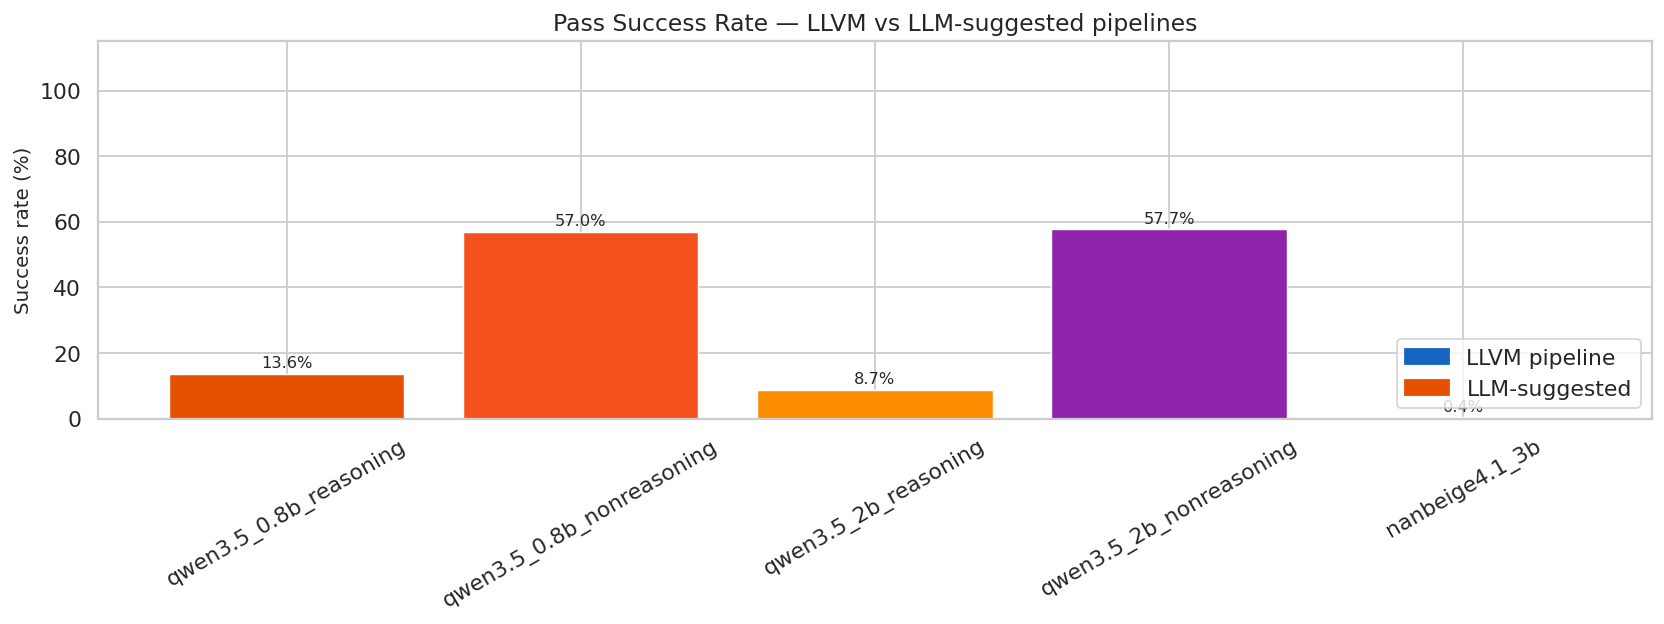

In [50]:
rated = df[~df["pipeline"].isin(["base_ir"]) & (df["status"] != "skip")]
sr = (
    rated.groupby("pipeline")["status"]
    .apply(lambda s: s.eq("ok").sum() / len(s) * 100)
    .reindex(pipes).dropna().reset_index(name="rate")
)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(
    sr["pipeline"], sr["rate"],
    color=[cmap.get(p, "#aaa") for p in sr["pipeline"]],
    edgecolor="white", linewidth=0.8,
)
ax.set_ylim(0, 115)
ax.set_ylabel("Success rate (%)")
ax.set_title("Pass Success Rate — LLVM vs LLM-suggested pipelines")
ax.tick_params(axis="x", rotation=30)
for b, v in zip(bars, sr["rate"]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1,
            f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
ax.legend(handles=LEGEND, loc="lower right")
plt.tight_layout(); save("01_success_rate")

### 8.2 · Executable size — box plot

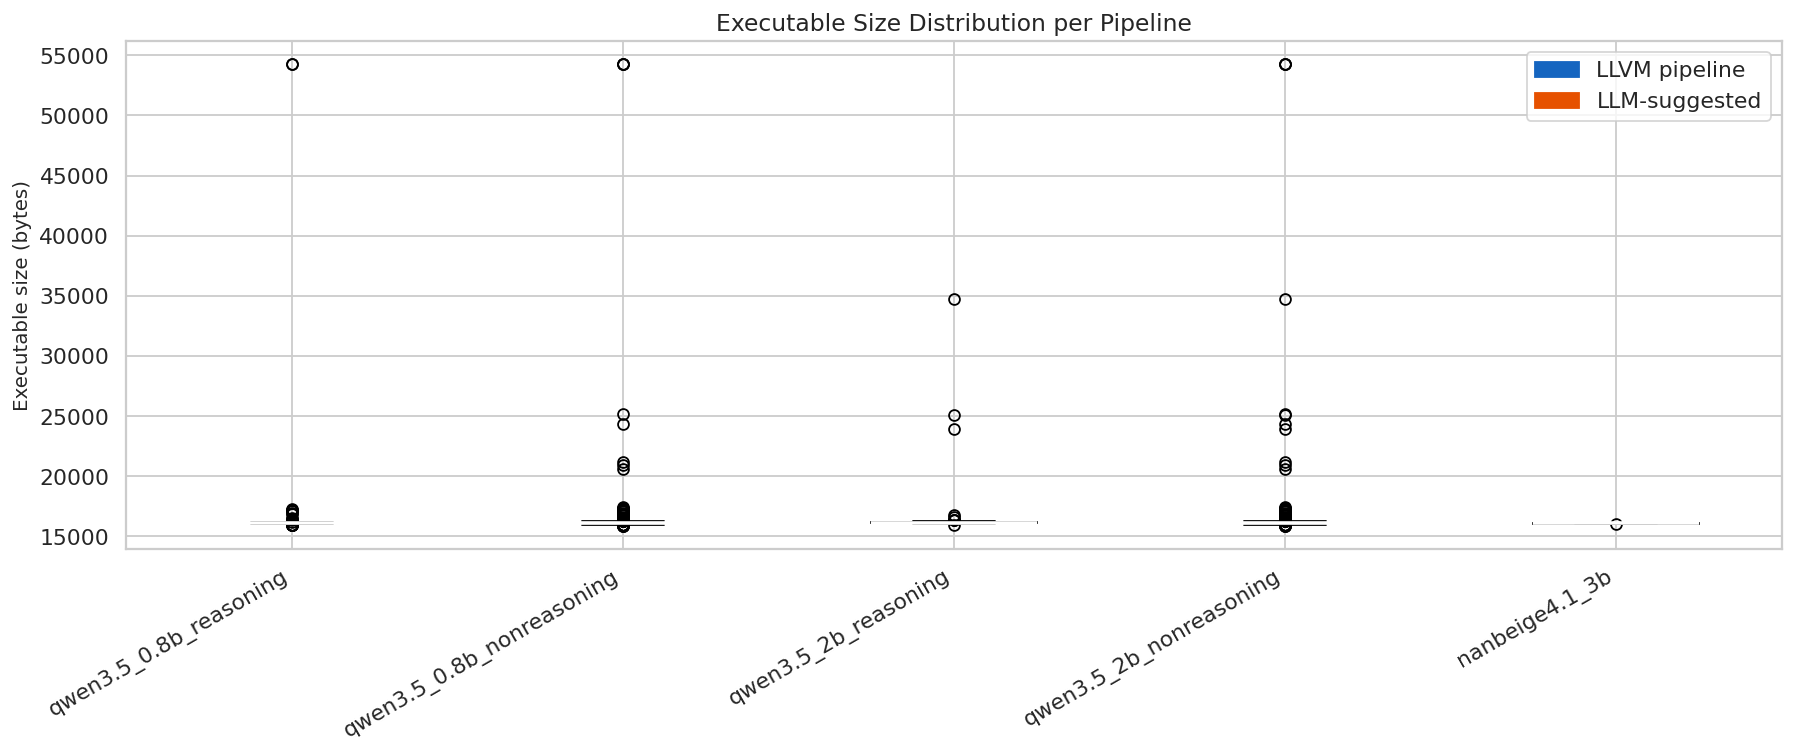

In [51]:
ppl  = [p for p in pipes if p in ok_df["pipeline"].values]
data = [ok_df[ok_df["pipeline"] == p]["exe_size"].dropna().values for p in ppl]

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(data, patch_artist=True, notch=False,
                medianprops=dict(color="white", linewidth=2))
for patch, p in zip(bp["boxes"], ppl):
    patch.set_facecolor(cmap.get(p, "#999"))
    patch.set_alpha(0.85)
ax.set_xticks(range(1, len(ppl)+1))
ax.set_xticklabels(ppl, rotation=30, ha="right")
ax.set_ylabel("Executable size (bytes)")
ax.set_title("Executable Size Distribution per Pipeline")
ax.legend(handles=LEGEND)
plt.tight_layout(); save("02_exe_size_box")

### 8.3 · Size reduction vs baseline (%)

In [52]:
if delta_df.empty:
    print("No baseline comparison data — skipping.")
else:
    piv = (
        delta_df[delta_df["pipeline"] != "baseline"]
        .groupby("pipeline")["size_pct"].mean()
        .reindex(pipes).dropna().sort_values().reset_index(name="delta")
    )
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(
        piv["pipeline"], piv["delta"],
        color=[cmap.get(p, "#999") for p in piv["pipeline"]],
        edgecolor="white", linewidth=0.6,
    )
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Average size change vs baseline (%)")
    ax.set_title("Size Reduction vs Baseline  (negative = smaller = better)")
    for i, (_, row) in enumerate(piv.iterrows()):
        v = row["delta"]
        ax.text(v + (0.3 if v >= 0 else -0.3), i, f"{v:+.2f}%",
                va="center", ha="left" if v >= 0 else "right", fontsize=9)
    ax.legend(handles=LEGEND)
    plt.tight_layout(); save("03_size_delta")

No baseline comparison data — skipping.


### 8.4 · Compile time — violin

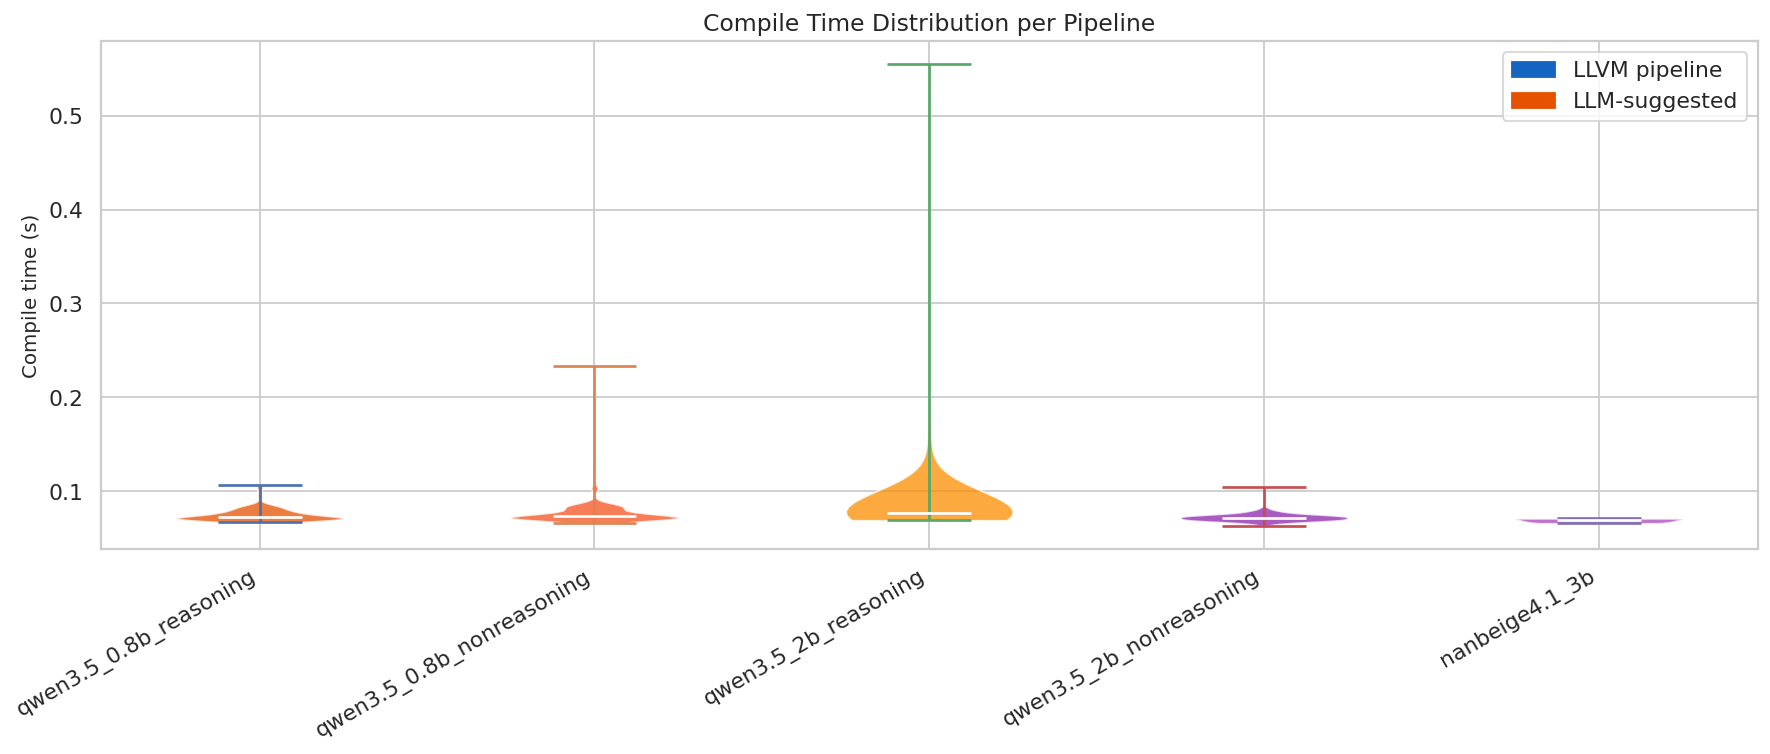

In [53]:
t_df = ok_df[ok_df["compile_time_s"].notna()]
ppl  = [p for p in pipes if p in t_df["pipeline"].values]

fig, ax = plt.subplots(figsize=(14, 6))
for i, p in enumerate(ppl, 1):
    vals = t_df[t_df["pipeline"] == p]["compile_time_s"].values
    if len(vals) < 3: continue
    parts = ax.violinplot(vals, positions=[i], showmedians=True)
    for pc in parts["bodies"]:
        pc.set_facecolor(cmap.get(p, "#999"))
        pc.set_alpha(0.75)
    parts["cmedians"].set_color("white")
ax.set_xticks(range(1, len(ppl)+1))
ax.set_xticklabels(ppl, rotation=30, ha="right")
ax.set_ylabel("Compile time (s)")
ax.set_title("Compile Time Distribution per Pipeline")
ax.legend(handles=LEGEND)
plt.tight_layout(); save("04_compile_time_violin")

### 8.5 · LLM inference time — overlapping histogram

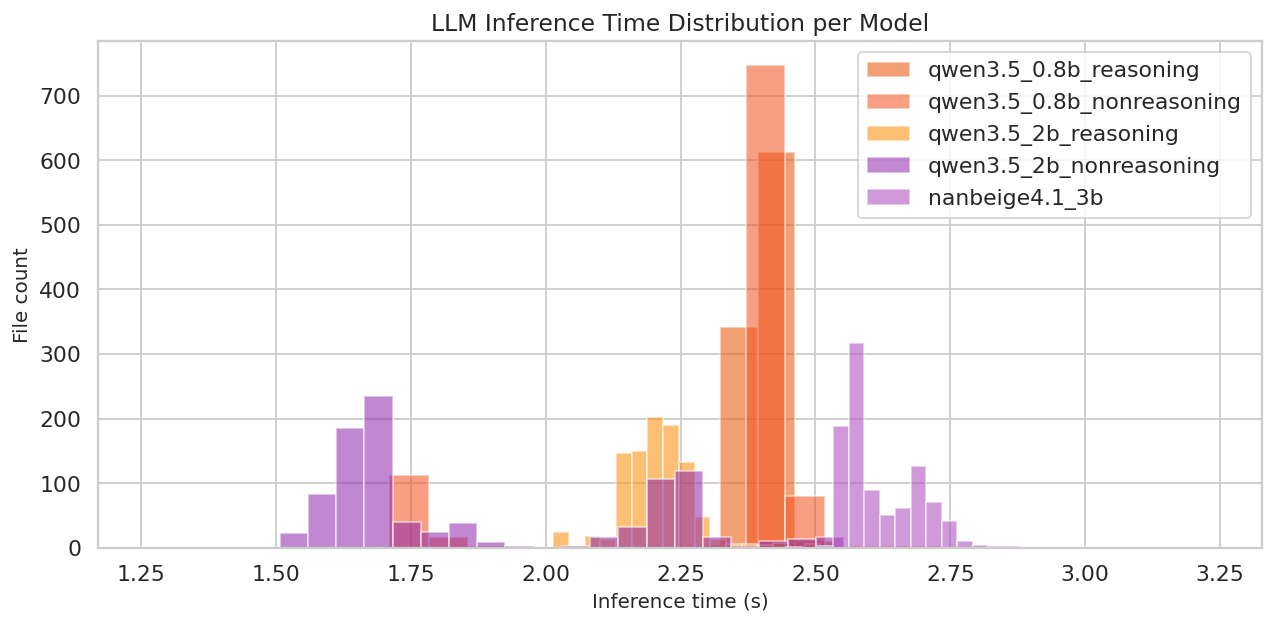

In [54]:
llm_inf = df[df["pipeline"].isin(ALL_LLM) & df["llm_infer_s"].notna()]

if llm_inf.empty:
    print("No LLM inference data yet — run section 5 first.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    for p in ALL_LLM:
        vals = llm_inf[llm_inf["pipeline"] == p]["llm_infer_s"].values
        if len(vals) == 0: continue
        ax.hist(vals, bins=20, alpha=0.55, label=p, color=cmap.get(p,"#999"))
    ax.set_xlabel("Inference time (s)")
    ax.set_ylabel("File count")
    ax.set_title("LLM Inference Time Distribution per Model")
    ax.legend()
    plt.tight_layout(); save("05_llm_infer_hist")

### 8.6 · Inference time vs compile success (strip plot)

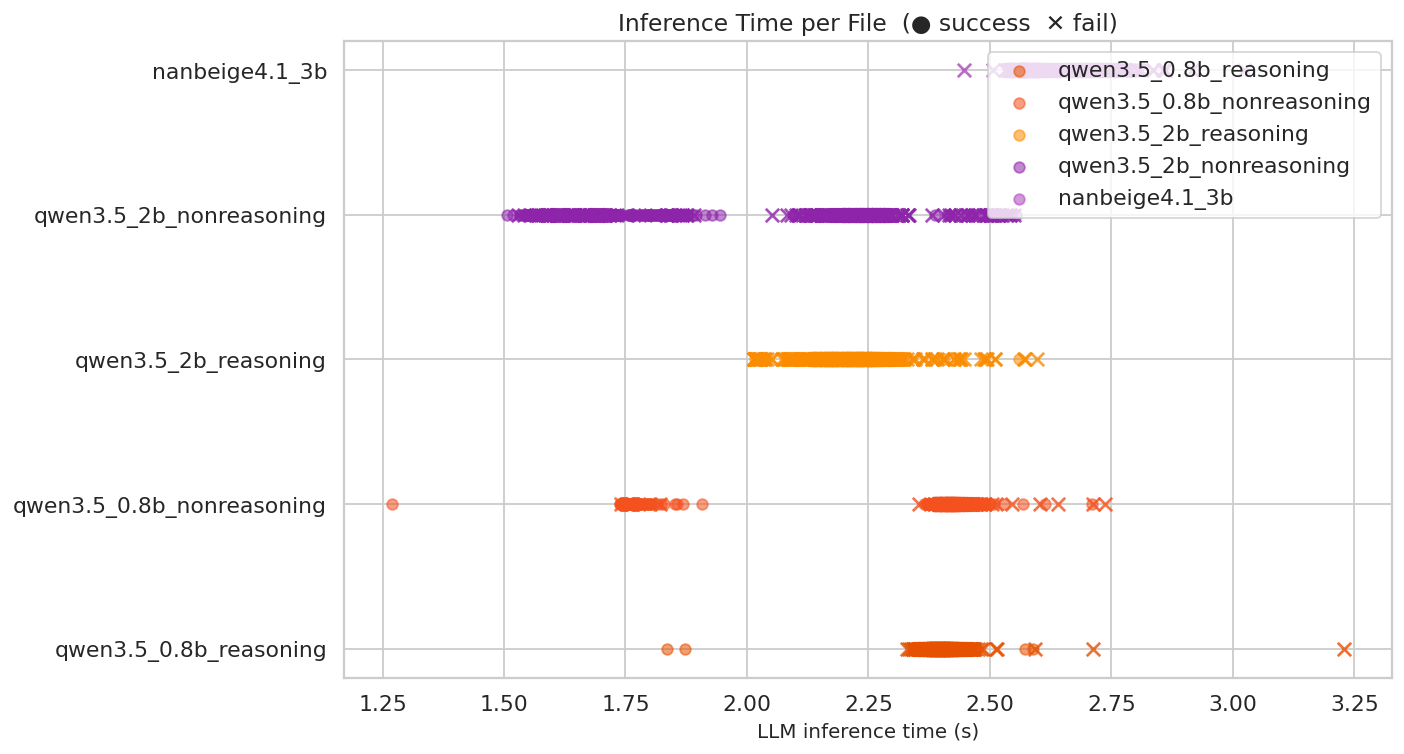

In [55]:
if llm_inf.empty:
    print("No LLM inference data.")
else:
    fig, ax = plt.subplots(figsize=(11, 6))
    for p in ALL_LLM:
        sub  = llm_inf[llm_inf["pipeline"] == p]
        ok_t = sub[sub["status"] == "ok"]["llm_infer_s"]
        fl_t = sub[sub["status"] != "ok"]["llm_infer_s"]
        ax.scatter(ok_t, [p]*len(ok_t),   c=cmap.get(p,"#999"),
                   marker="o", s=35, alpha=0.55, label=p)
        ax.scatter(fl_t, [p]*len(fl_t),   c=cmap.get(p,"#999"),
                   marker="x", s=55, alpha=0.8)
    # deduplicate legend
    h, l = ax.get_legend_handles_labels()
    ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(),
              loc="upper right")
    ax.set_xlabel("LLM inference time (s)")
    ax.set_title("Inference Time per File  (● success  ✕ fail)")
    plt.tight_layout(); save("06_llm_infer_scatter")

### 8.7 · Heatmap — pipeline × 4 metrics (normalised + raw annotations)

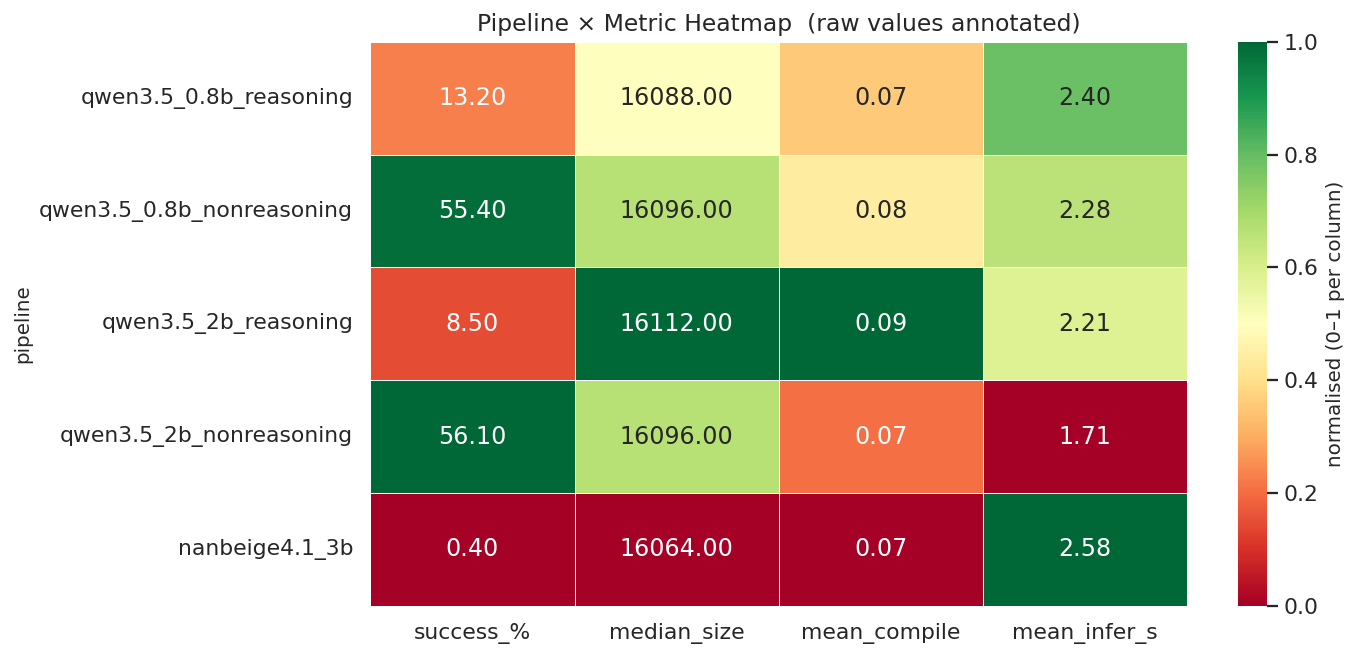

In [56]:
metrics = []
for p in [pp for pp in pipes if pp != "base_ir"]:
    sub = df[df["pipeline"] == p]
    ok  = sub[sub["status"] == "ok"]
    row = {
        "pipeline":     p,
        "success_%":    round(sub["status"].eq("ok").mean() * 100, 1),
        "median_size":  round(ok["exe_size"].median(), 0) if len(ok) else np.nan,
        "mean_compile": round(ok["compile_time_s"].mean(), 5) if len(ok) else np.nan,
        "mean_infer_s": round(ok["llm_infer_s"].mean(), 4)
                        if ok["llm_infer_s"].notna().any() else np.nan,
    }
    if not delta_df.empty:
        dm = delta_df[delta_df["pipeline"] == p]["size_pct"]
        row["size_delta_%"] = round(dm.mean(), 3) if len(dm) else np.nan
    metrics.append(row)

heat_raw  = pd.DataFrame(metrics).set_index("pipeline")
heat_norm = heat_raw.copy()
for col in heat_norm.columns:
    mn, mx = heat_norm[col].min(), heat_norm[col].max()
    if mx > mn:
        heat_norm[col] = (heat_norm[col] - mn) / (mx - mn)

fig, ax = plt.subplots(figsize=(11, 0.55*len(heat_raw)+2.5))
sns.heatmap(heat_norm, annot=heat_raw.round(2), fmt=".2f",
            cmap="RdYlGn", linewidths=0.5, ax=ax,
            cbar_kws={"label": "normalised (0–1 per column)"})
ax.set_title("Pipeline × Metric Heatmap  (raw values annotated)")
plt.tight_layout(); save("07_heatmap")

### 8.8 · Per-file size: each LLM vs O3 (parity scatter)

No LLVM baseline rows available for parity comparison.


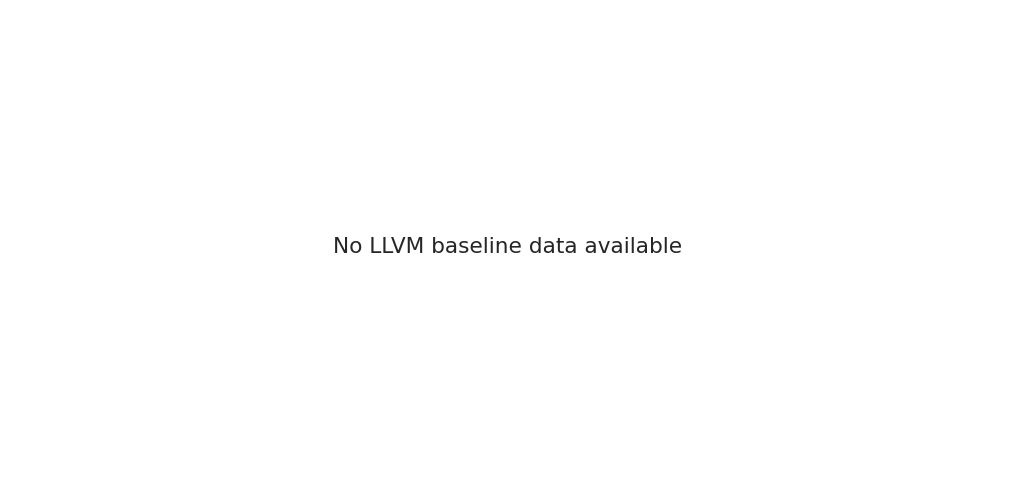

In [57]:
# Robust parity plot: handle source key mismatches and baseline naming variations
ok_sizes = ok_df[ok_df["exe_size"].notna()].copy()

def canonical_source_key(s):
    s = str(s).strip().replace("\\", "/")
    while s.startswith("./"):
        s = s[2:]
    return s

if ok_sizes.empty:
    print("No successful rows with executable size found.")
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.text(0.5, 0.5, "No size data available", ha="center", va="center", fontsize=12)
    ax.axis("off")
    plt.tight_layout(); save("08_llm_vs_o3")
else:
    ok_sizes["src_key"] = ok_sizes["source"].map(canonical_source_key)

    # Prefer O3; fallback to common LLVM baselines if naming differs.
    baseline_candidates = ["O3", "-O3", "Oz", "-Oz", "O2", "-O2", "O1", "-O1"]
    baseline_name = None
    for b in baseline_candidates:
        if not ok_sizes[ok_sizes["pipeline"] == b].empty:
            baseline_name = b
            break

    if baseline_name is None:
        llvm_counts = (
            ok_sizes[ok_sizes["pipeline"].isin(ALL_LLVM)]
            .groupby("pipeline")["src_key"]
            .nunique()
            .sort_values(ascending=False)
        )
        if llvm_counts.empty:
            print("No LLVM baseline rows available for parity comparison.")
            fig, ax = plt.subplots(figsize=(8, 4))
            ax.text(0.5, 0.5, "No LLVM baseline data available", ha="center", va="center", fontsize=12)
            ax.axis("off")
            plt.tight_layout(); save("08_llm_vs_o3")
        else:
            baseline_name = llvm_counts.index[0]

    if baseline_name is not None:
        o_base = (
            ok_sizes[ok_sizes["pipeline"] == baseline_name]
            .groupby("src_key")["exe_size"]
            .min()
        )

        ncols = 3
        nrows = -(-len(ALL_LLM) // ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
        axes = axes.flatten()

        total_pairs = 0
        for i, p in enumerate(ALL_LLM):
            ax = axes[i]
            llm_s = (
                ok_sizes[ok_sizes["pipeline"] == p]
                .groupby("src_key")["exe_size"]
                .min()
            )
            common = o_base.index.intersection(llm_s.index)

            if len(common) == 0:
                ax.set_title(f"{p}\n(no overlapping files)")
                ax.set_xlabel(f"{baseline_name} size (bytes)")
                ax.set_ylabel(f"{p} size (bytes)")
                continue

            x = o_base.loc[common].values
            y = llm_s.loc[common].values
            total_pairs += len(common)

            ax.scatter(x, y, alpha=0.45, s=18, color=cmap.get(p, "#888"))
            lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
            ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="parity")
            ax.set_xlabel(f"{baseline_name} size (bytes)")
            ax.set_ylabel(f"{p} size (bytes)")
            ax.set_title(f"{p} vs {baseline_name}  (n={len(common)})")
            ax.legend(fontsize=8)

        for j in range(len(ALL_LLM), len(axes)):
            axes[j].set_visible(False)

        print(f"Baseline used for parity: {baseline_name}")
        print(f"Total overlapping model-file pairs plotted: {total_pairs}")

        fig.suptitle(f"Per-file Executable Size: LLM-suggested vs LLVM {baseline_name}",
                     fontsize=14, y=1.01)
        plt.tight_layout(); save("08_llm_vs_o3")

## 9 · Numeric summary table

In [58]:
summary = pd.DataFrame(metrics)
summary.insert(1, "kind",
    summary["pipeline"].map(lambda p: "LLM" if p in ALL_LLM else "LLVM"))
print(summary.to_string(index=False))

                 pipeline kind  success_%  median_size  mean_compile  mean_infer_s
   qwen3.5_0.8b_reasoning  LLM       13.2      16088.0       0.07474        2.3954
qwen3.5_0.8b_nonreasoning  LLM       55.4      16096.0       0.07621        2.2778
     qwen3.5_2b_reasoning  LLM        8.5      16112.0       0.08558        2.2144
  qwen3.5_2b_nonreasoning  LLM       56.1      16096.0       0.07222        1.7066
           nanbeige4.1_3b  LLM        0.4      16064.0       0.06876        2.5768


## 10 · Most frequent pass strings per LLM

In [59]:
from collections import Counter

for p in ALL_LLM:
    sub = df[(df["pipeline"] == p) & df["llm_raw_output"].notna()]
    if sub.empty: continue
    top = Counter(sub["llm_raw_output"]).most_common(10)
    print(f"\n── {p} ── top-10 suggested pipelines:")
    for ps, cnt in top:
        ok_n = sub[sub["llm_raw_output"] == ps]["status"].eq("ok").sum()
        print(f"  {cnt:3}× (ok={ok_n})  {ps}")


── qwen3.5_0.8b_reasoning ── top-10 suggested pipelines:
   53× (ok=44)  instcombine,dce,sccp
   51× (ok=47)  instcombine,dce
   20× (ok=20)  mem2reg,instcombine,simplifycfg,gvn,licm,loop-unroll,dce
   17× (ok=0)  Thinking Process:

1.  **Analyze the Request:**
    *   **Input:** LLVM IR code containing a function definition `@polybench_flush_cache` and a `define` statement.
    *   **Task:** Optimize the provi
   15× (ok=12)  mem2reg,instcombine
    8× (ok=0)  Thinking Process:

1.  **Analyze the Request:**
    *   **Input:** LLVM IR code containing function definitions (`define dso_local`, `define dso_local`).
    *   **Task:** Optimize the provided LLVM I
    7× (ok=0)  33333333333333333333333333333333333333333333333333333333333333333333333333333333
    7× (ok=0)  Thinking Process:

1.  **Analyze the Request:**
    *   **Input:** LLVM IR code containing multiple functions (`dso_local`, `main`).
    *   **Task:** Optimize the provided LLVM IR using a specific se
    7× (ok=0)  Think

## 11 · Export all plots to a single PDF

In [60]:
from matplotlib.backends.backend_pdf import PdfPages
import glob

plots = sorted(glob.glob("plot_*.png"))
if plots:
    with PdfPages("llm_llvm_report.pdf") as pdf:
        for pf in plots:
            img = plt.imread(pf)
            fig, ax = plt.subplots(figsize=(12, 7))
            ax.imshow(img); ax.axis("off")
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)
    print(f"Saved: llm_llvm_report.pdf  ({len(plots)} pages)")
else:
    print("No plots found — run section 8 first.")

Saved: llm_llvm_report.pdf  (7 pages)
